# Heart Disease Prediction — ML Classification Project

I picked this dataset because I wanted to work on something with a real consequence — not just accuracy on paper, but a case where a wrong prediction actually means something.

The goal here is a full binary classification pipeline: data checks, EDA, three models, honest evaluation. I also used this project to work through things I kept getting confused about — mainly data leakage and why accuracy isn't always the right metric to optimize.


In [1]:
import numpy as np            # numerical operations
import pandas as pd           # data manipulation
import matplotlib.pyplot as plt  # plotting
import seaborn as sns         # statistical visualization 
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully')


All libraries imported successfully


## 1. Load Dataset

I start by loading the CSV file into a pandas DataFrame.

At this point, I only want to get a first look at the data: what the rows look like, how many columns there are, and what kind of features I am working with.


In [2]:
df = pd.read_csv("../data/heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.shape


(1025, 14)

In [4]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Initial Dataset Overview

The dataset starts with 1025 rows and 14 columns. Each row represents one patient, and the columns describe medical features such as age, cholesterol, resting blood pressure, maximum heart rate, and chest pain type.

The target column is `target`:
- `0` means no heart disease
- `1` means heart disease

All columns are numeric, which is convenient for the models I plan to use. From `df.info()`, there are no obvious missing values at this point.


## 2. Data Quality Check

Before touching EDA or models, I check the raw state of the data.

I learned this the hard way — I once spent time building a model only to realize the dataset had duplicate rows that ended up in both train and test sets. The evaluation looked fine but was essentially measuring how well the model memorized training data.

Here I check three things: missing values, duplicates, and basic statistics.


In [6]:
# Check missing values in each column

df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Display duplicated rows

df[df.duplicated()]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
# Basic statistics for numerical columns

df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Data Quality Findings

No missing values — straightforward.

The duplicate situation is more interesting: 722 out of 1025 rows are duplicates. That's a lot. If I split first and remove duplicates after, the same patient record can appear in both train and test sets. The model evaluates on data it has already seen — the test score becomes meaningless.

So duplicates go before the split. The dataset shrinks to ~303 rows, but the evaluation is honest.


In [9]:
# Remove duplicated rows

df = df.drop_duplicates()


In [10]:
# Check the new dataset shape after removing duplicates

df.shape


(302, 14)

In [11]:
# Check duplicated rows again

df.duplicated().sum()


np.int64(0)

### Categorical Feature Check

Some columns are stored as numbers, but they actually represent categories.

I check their unique values to make sure there are no unexpected labels before moving further.


In [12]:
# Columns that are encoded as numbers but represent categories

categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

for col in categorical_columns:
    print(col, ":", sorted(df[col].unique()))


sex : [np.int64(0), np.int64(1)]
cp : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs : [np.int64(0), np.int64(1)]
restecg : [np.int64(0), np.int64(1), np.int64(2)]
exang : [np.int64(0), np.int64(1)]
slope : [np.int64(0), np.int64(1), np.int64(2)]
ca : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
target : [np.int64(0), np.int64(1)]


### Renaming Columns

Some original column names are short medical abbreviations. I rename them to make the notebook easier to read.

This does not change the data itself. It only makes later tables, plots, and feature importance easier to understand.


In [13]:
# Rename columns for better readability

df = df.rename(columns={
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "resting_ecg",
    "thalach": "max_heart_rate",
    "exang": "exercise_angina",
    "oldpeak": "st_depression",
    "ca": "num_major_vessels"
})


In [14]:
# Check updated column names

df.columns


Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression', 'slope', 'num_major_vessels',
       'thal', 'target'],
      dtype='str')

## 3. Target Distribution

The target column shows whether a patient has heart disease.

Before training models, I check the class balance. If one class is much larger than the other, accuracy can become misleading.


In [15]:
# Count how many samples belong to each class

df["target"].value_counts()


target
1    164
0    138
Name: count, dtype: int64

In [16]:
df["target"].value_counts(normalize=True) * 100


target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

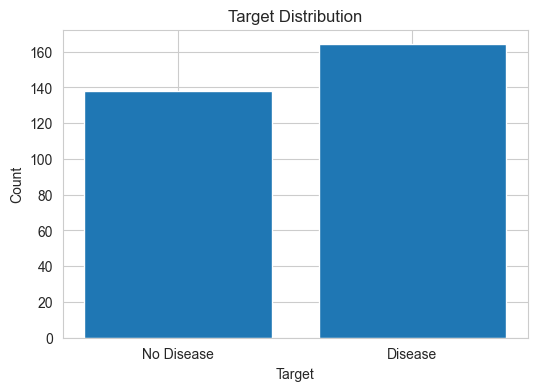

In [17]:
# Plot target distribution

target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()


### Target Distribution Summary

The target classes are fairly balanced. This means accuracy can still be useful as a general metric.

However, this is a medical classification task, so accuracy alone is not enough. I also need to look at precision, recall, F1-score, and the confusion matrix.

Recall is especially important because missing a patient with heart disease is a serious type of mistake.


### Why Accuracy Is Not Enough

Géron has a good example in Chapter 3: a classifier that always predicts "not 5" on the MNIST dataset gets 90% accuracy. It's also completely useless for finding 5s.

The same logic applies here. With ~50/50 class balance, a model predicting the majority class gets ~54% accuracy. That's not far from what a bad model could achieve while still looking reasonable on paper.

More importantly — in a medical task, the two types of errors aren't equal. A false negative means a sick patient is told they're fine. A false positive means extra tests. One of those is clearly worse.

So I track recall separately, not just F1 or accuracy.


## 4. Exploratory Data Analysis

Before training models, I want to understand the dataset better.

In this section, I look for patterns between the features and the target. I do not expect one feature to explain everything, but EDA can show which variables may be useful for classification.


In [18]:
# Compare mean feature values for patients with and without heart disease

df.groupby("target").mean()


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,slope,num_major_vessels,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.585366,0.560976,1.371951,129.250000,242.640244,0.140244,0.591463,158.378049,0.140244,0.586585,1.591463,0.341463,2.121951


### Mean Feature Comparison

I start EDA with a simple comparison of average feature values for both target classes.

This is only a first check. Some features are categorical, so their averages are not always easy to interpret. Still, this table helps me notice which features may be worth visualizing next.


In [19]:
# Transpose the mean table to make it easier to compare target classes

mean_by_target = df.groupby("target").mean().T

mean_by_target


target,0,1
age,56.601449,52.585366
sex,0.826087,0.560976
chest_pain_type,0.478261,1.371951
resting_blood_pressure,134.398551,129.250000
cholesterol,251.086957,242.640244
fasting_blood_sugar,0.159420,0.140244
resting_ecg,0.449275,0.591463
max_heart_rate,139.101449,158.378049
exercise_angina,0.550725,0.140244
st_depression,1.585507,0.586585


In [20]:
# Calculate the difference between the two target classes

mean_by_target["difference"] = mean_by_target[1] - mean_by_target[0]

mean_by_target.sort_values(by="difference", ascending=False)


target,0,1,difference
max_heart_rate,139.101449,158.378049,19.276600
chest_pain_type,0.478261,1.371951,0.893690
slope,1.166667,1.591463,0.424797
resting_ecg,0.449275,0.591463,0.142188
fasting_blood_sugar,0.159420,0.140244,-0.019176
sex,0.826087,0.560976,-0.265111
exercise_angina,0.550725,0.140244,-0.410481
thal,2.543478,2.121951,-0.421527
num_major_vessels,1.166667,0.341463,-0.825203
st_depression,1.585507,0.586585,-0.998922


### Mean Comparison Observation

This table gives me a rough first idea of how the two classes differ.

A few features stand out, especially `max_heart_rate`, `chest_pain_type`, `st_depression`, and `num_major_vessels`. At this point, I do not treat them as definitely important, but they look interesting enough to check visually.

Because some of these variables are categorical, I avoid making strong conclusions from averages alone.


### Numerical Features Overview

Next, I look at the numerical features as a group.

For these features, histograms are useful because they show whether the two classes have different distributions or mostly overlap.


In [21]:
# Select numerical features for distribution analysis

numerical_features = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate",
    "st_depression"
]


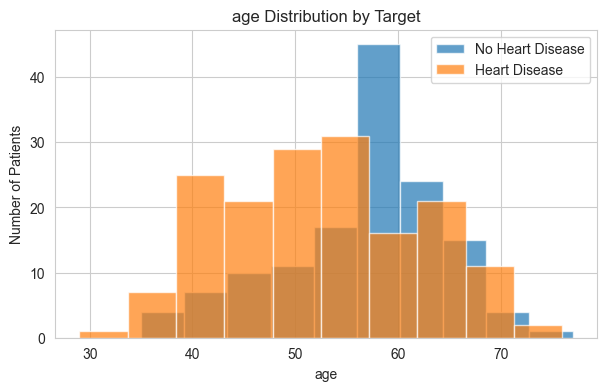

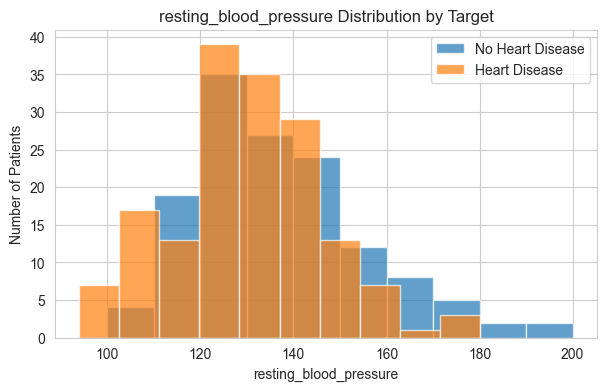

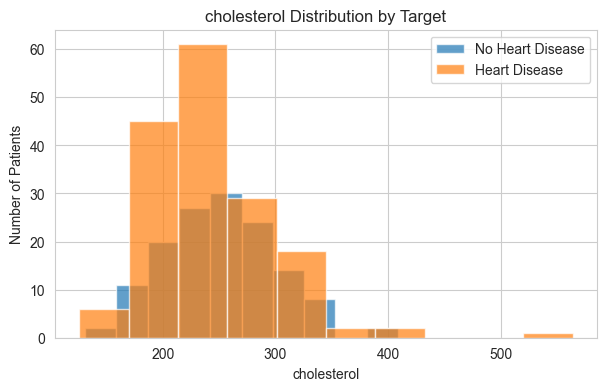

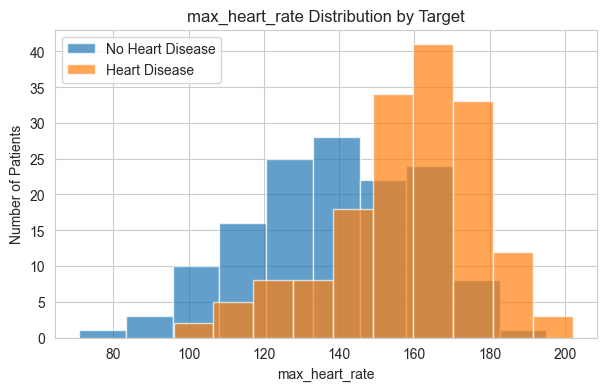

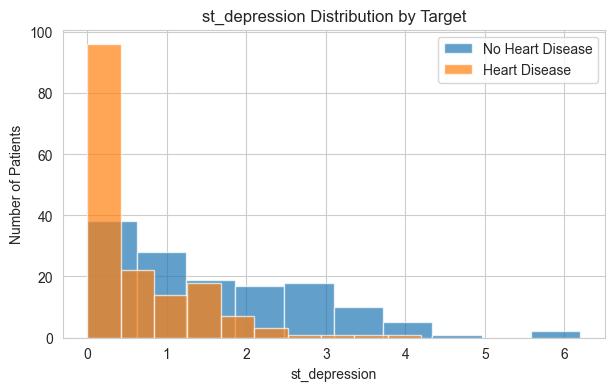

In [22]:
# Plot numerical feature distributions by target

for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    
    plt.hist(df[df["target"] == 0][feature], alpha=0.7, label="No Heart Disease")
    plt.hist(df[df["target"] == 1][feature], alpha=0.7, label="Heart Disease")
    
    plt.title(f"{feature} Distribution by Target")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.legend()
    
    plt.show()


### Categorical Features Overview

Some features are encoded as numbers, but they represent categories rather than continuous values.

For these columns, bar charts are easier to read than histograms. I use them to see whether some categories appear more often in one target class.


In [23]:
# Select categorical features

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_angina",
    "slope",
    "num_major_vessels",
    "thal"
]


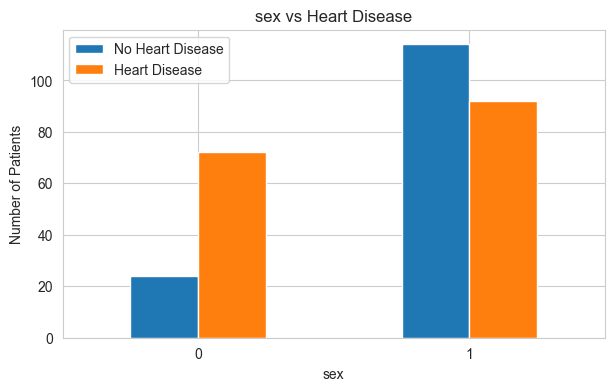

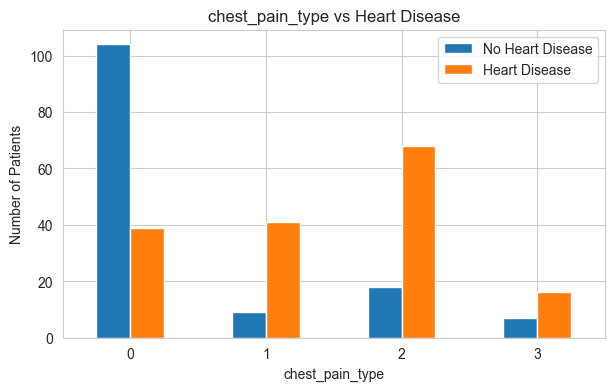

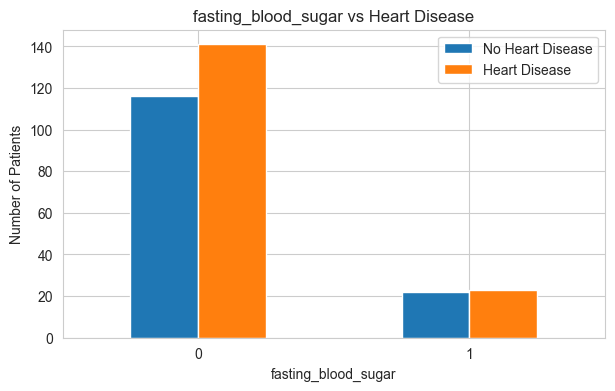

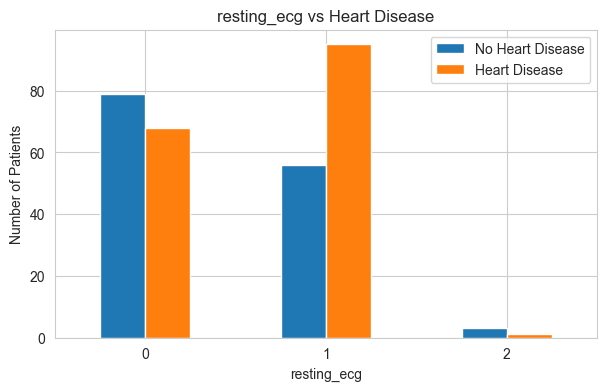

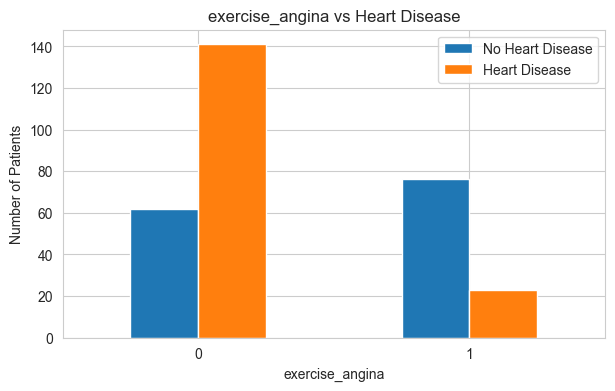

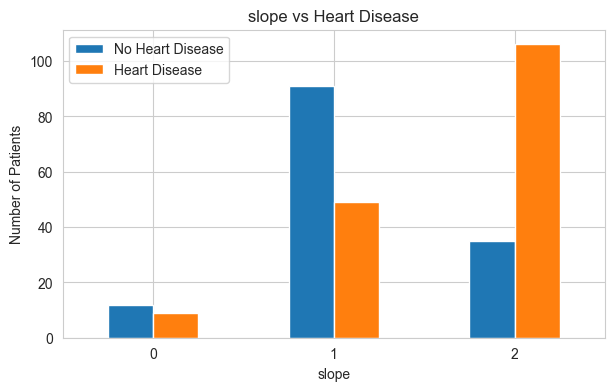

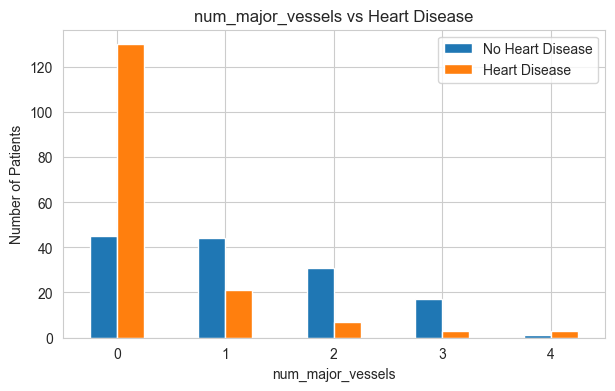

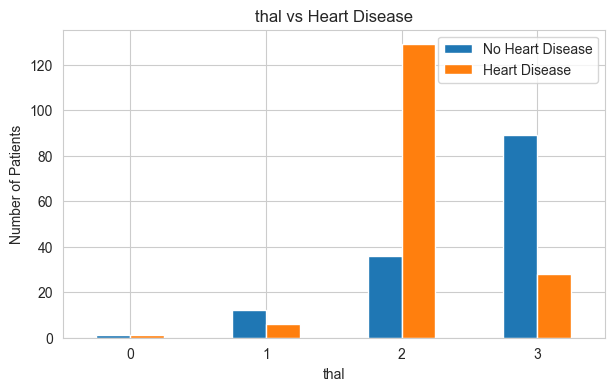

In [24]:
# Plot categorical features against target

for feature in categorical_features:
    table = pd.crosstab(df[feature], df["target"])
    
    table.plot(kind="bar", figsize=(7, 4))
    
    plt.title(f"{feature} vs Heart Disease")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=0)
    plt.legend(["No Heart Disease", "Heart Disease"])
    
    plt.show()


### Categorical Features Observation

The categorical features show clearer separation than some numerical features.

From the plots, `chest_pain_type`, `exercise_angina`, `num_major_vessels`, and `thal` seem especially useful. I still keep this as an EDA observation only, because the models will give a better test of how useful these features really are.


### Correlation Overview

After the plots, I also check correlations with the target.

Correlation is a quick numerical check, but it is not final proof of feature importance. It only captures simple linear relationships, while machine learning models can use combinations of features.


In [25]:
# Calculate correlation of each feature with the target variable

target_correlation = df.corr()["target"].sort_values(ascending=False)

target_correlation


target                    1.000000
chest_pain_type           0.432080
max_heart_rate            0.419955
slope                     0.343940
resting_ecg               0.134874
fasting_blood_sugar      -0.026826
cholesterol              -0.081437
resting_blood_pressure   -0.146269
age                      -0.221476
sex                      -0.283609
thal                     -0.343101
num_major_vessels        -0.408992
st_depression            -0.429146
exercise_angina          -0.435601
Name: target, dtype: float64

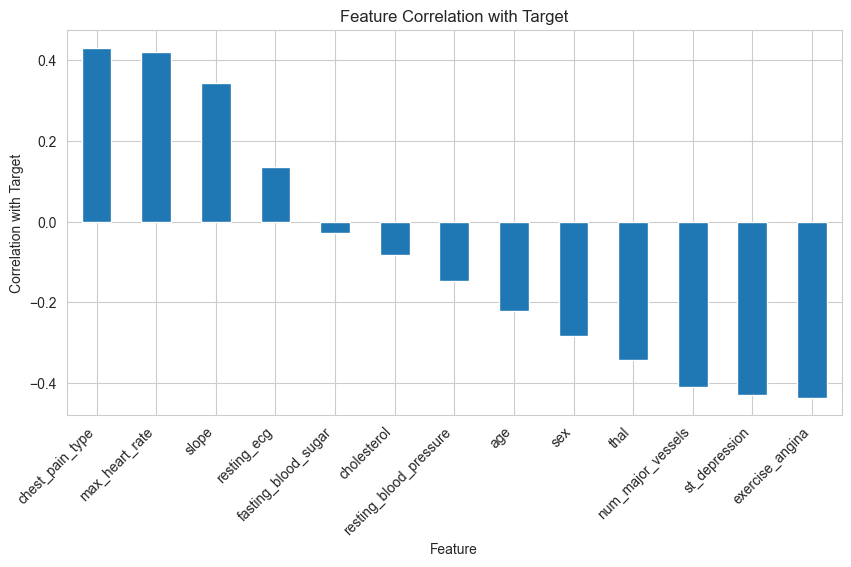

In [26]:
# Plot feature correlations with the target variable

target_correlation.drop("target").plot(kind="bar", figsize=(10, 5))

plt.title("Feature Correlation with Target")
plt.xlabel("Feature")
plt.ylabel("Correlation with Target")
plt.xticks(rotation=45, ha="right")

plt.show()


### Full Correlation Heatmap

The heatmap shows pairwise Pearson correlations between all features and the target variable.

I use it mostly as a compact overview. It helps me see not only which features are related to the target, but also whether some features are related to each other.


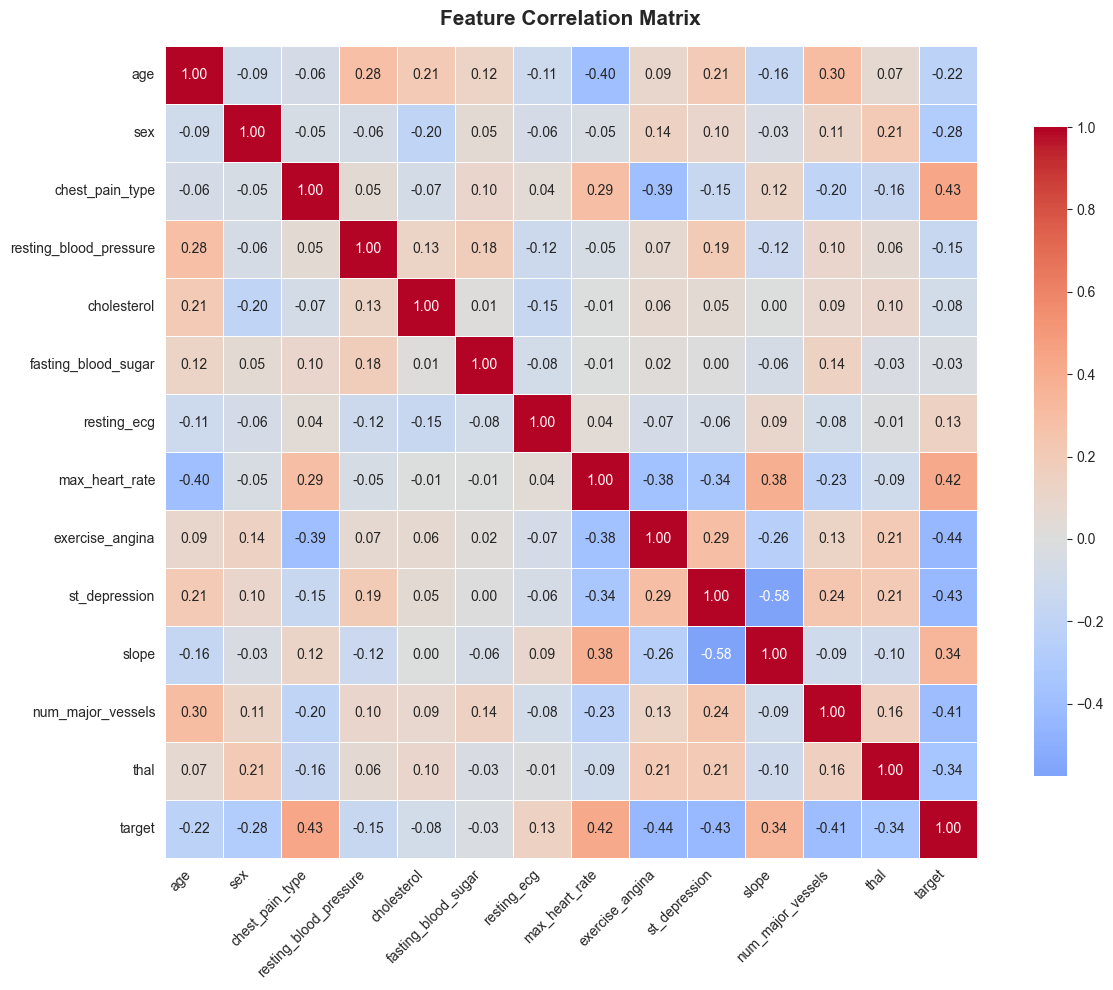


Top correlations with target:
exercise_angina           0.436
chest_pain_type           0.432
st_depression             0.429
max_heart_rate            0.420
num_major_vessels         0.409
slope                     0.344
thal                      0.343
sex                       0.284
age                       0.221
resting_blood_pressure    0.146
resting_ecg               0.135
cholesterol               0.081
fasting_blood_sugar       0.027
Name: target, dtype: float64


In [27]:
# Compute Pearson correlation matrix for the entire dataset
corr_matrix = df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True, 
    fmt='.2f',  
    cmap='coolwarm',  # red=positive, blue=negative
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Features most correlated with target — potential strong predictors
print('\nTop correlations with target:')
print(corr_matrix['target'].drop('target').abs().sort_values(ascending=False).round(3))


### Correlation Observation

The correlation results support some of the patterns from the visual analysis.

Some features are more related to the target than others, but I do not use correlation as the final measure of importance. It is only one part of understanding the dataset.


## 5. Preprocessing

Three steps: separate features from target, split into train/test, scale for Logistic Regression.

The order matters more than it seems. If I scale the full dataset before splitting, the scaler sees test set values during fitting — mean and standard deviation are calculated using test data. That's data leakage. Small effect on metrics, but wrong in principle.

Scale after split. Fit scaler on train only. Apply to test.


In [28]:
# Separate input features and target variable

X = df.drop("target", axis=1)
y = df["target"]
# Check feature matrix and target vector shapes

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (302, 13)
y shape: (302,)


### Train/Test Split

I split the dataset into training and testing sets.

The training set is used to fit the models. The test set is kept separate so I can check how the models perform on data they did not see during training.


In [29]:
from sklearn.model_selection import train_test_split


In [30]:
# Split data into training and testing sets
# test_size=0.25 gives more test samples on this small dataset after deduplication

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,  # 25% test
    random_state=42,
    stratify=y  # preserve class ratio
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)


X_train shape: (226, 13)
X_test shape:  (76, 13)
y_train shape: (226,)
y_test shape:  (76,)


### Feature Scaling

Decision Tree and Random Forest don't need scaling — they work with thresholds, so absolute feature values don't matter.

Logistic Regression does. Features like `cholesterol` sit around 200, while `fasting_blood_sugar` is 0 or 1. Without scaling the optimizer treats a 1-unit change in cholesterol the same as a 1-unit change in blood sugar — which makes no sense.

`StandardScaler` fixes this: mean 0, std 1 for every feature. Fitted on train data only, then applied to test.


In [31]:
from sklearn.preprocessing import StandardScaler


In [32]:
# Create a StandardScaler object

scaler = StandardScaler()

# Fit the scaler only on the training data and transform the training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the scaler fitted on the training data

X_test_scaled = scaler.transform(X_test)


In [33]:
# Check scaled data shapes

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (226, 13)
X_test_scaled shape: (76, 13)


In [34]:
# Convert scaled arrays back to DataFrames for readability

X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)


In [35]:
X_train_scaled.head()


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,slope,num_major_vessels,thal
19,0.410557,0.697741,0.994167,0.515901,-0.676764,2.508052,-1.013295,0.611286,-0.656033,-0.851400,0.939805,-0.736125,-0.531487
104,-0.246722,0.697741,1.966815,-0.804933,-1.153240,-0.398716,-1.013295,1.717907,-0.656033,-0.851400,-0.706675,-0.736125,-2.133036
85,-1.123095,0.697741,0.021519,-0.684857,-0.505233,-0.398716,0.863792,0.832610,-0.656033,-0.851400,0.939805,-0.736125,-0.531487
8,-0.904002,0.697741,-0.951129,-0.684857,0.047479,-0.398716,-1.013295,-0.318276,-0.656033,-0.149150,0.939805,-0.736125,1.070061
29,0.081918,-1.433197,-0.951129,2.917417,1.534084,-0.398716,2.740879,-1.513427,1.524313,2.133161,-0.706675,-0.736125,-0.531487


### Preprocessing Summary

At this point, the data is ready for modeling.

I separated features and target, created a train/test split, and scaled the features for Logistic Regression. The scaler was fitted only on the training data, which helps avoid data leakage.


## 6. Baseline Model

Before training real models, I create a simple baseline.

The baseline always predicts the most frequent class from the training data. It does not learn from the medical features, but it gives me a minimum score to compare against.

If a real model cannot beat this baseline, then it is probably not useful.


In [36]:
# Import DummyClassifier for the baseline model

from sklearn.dummy import DummyClassifier


In [37]:
# Train the baseline model
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [38]:
# Make predictions on the test set

baseline_predictions = baseline_model.predict(X_test)


In [39]:
# Import metrics for model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [40]:
# Evaluate baseline model

print(classification_report(y_test, baseline_predictions))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.54      1.00      0.70        41

    accuracy                           0.54        76
   macro avg       0.27      0.50      0.35        76
weighted avg       0.29      0.54      0.38        76



In [41]:
# Import confusion_matrix only when I need it

from sklearn.metrics import confusion_matrix


In [42]:
# Show confusion matrix for the baseline model

baseline_cm = confusion_matrix(y_test, baseline_predictions)

baseline_cm


array([[ 0, 35],
       [ 0, 41]])

## 7. Logistic Regression

First real model. Logistic Regression fits a linear decision boundary — it finds the combination of features that best separates the two classes by modeling the probability of belonging to class 1.

I start here because it's interpretable and fast, and because a linear model is a reasonable first assumption before trying something more complex. If the classes are roughly linearly separable, Logistic Regression will find it cleanly.


In [43]:
# Import Logistic Regression model

from sklearn.linear_model import LogisticRegression


In [44]:
# Create Logistic Regression model for scaled data

log_reg = LogisticRegression(max_iter=1000, random_state=42)
# Train the model on scaled training data

log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [45]:
log_reg.score(X_test_scaled, y_test)


0.8026315789473685

In [46]:
# Make predictions on scaled test data

log_reg_predictions = log_reg.predict(X_test_scaled)

log_reg_predictions[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

### Logistic Regression Evaluation

I evaluate Logistic Regression using accuracy, precision, recall, and F1-score.

Accuracy gives the overall result, but recall and F1-score are more useful here because this is a medical classification problem.


In [47]:
# Create a helper function for model evaluation

def evaluate_classification_model(model_name, y_true, y_pred):
     return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }


In [48]:
log_reg_result = evaluate_classification_model("Logistic Regression",
    y_test, log_reg_predictions)

pd.DataFrame([log_reg_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.802632,0.782609,0.878049,0.827586


### Confusion Matrix

I also check the confusion matrix to see what kinds of mistakes the model makes.

For this project, false negatives are important because they mean the model predicts no heart disease when the patient actually has heart disease.


In [49]:
# Confusion matrix for Logistic Regression 
 
log_reg_cm = confusion_matrix(y_test, log_reg_predictions)
log_reg_cm


array([[25, 10],
       [ 5, 36]])

### Baseline vs Logistic Regression

I compare Logistic Regression with the baseline to check whether the model actually learned something useful from the features.


In [50]:
# Evaluate baseline using the same helper function

baseline_result = evaluate_classification_model("Baseline", y_test, baseline_predictions)


In [51]:
# Compare baseline with Logistic Regression

baseline_vs_log_reg = pd.DataFrame([baseline_result, log_reg_result])
baseline_vs_log_reg


,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.539474,0.539474,1.000000,0.700855
1,Logistic Regression,0.802632,0.782609,0.878049,0.827586


### Baseline Comparison Observation

Logistic Regression performs much better than the baseline.

The baseline has perfect recall because it predicts the positive class almost all the time, but its accuracy and precision are only about 0.54. Logistic Regression gives a better balance: accuracy is around 0.80, precision is around 0.78, recall is around 0.88, and F1-score is around 0.83.

This tells me that the model is using the medical features instead of only predicting the most frequent class.


## 8. Decision Tree Classifier

Decision Tree works differently — instead of a linear boundary, it creates a series of if-else rules based on feature thresholds. You can print the tree and follow every decision step by step.

The problem is that without any constraint, the tree keeps splitting until every training sample is in its own leaf. Training accuracy hits 1.0, test accuracy drops. That gap is overfitting — the model learned the training data, not the pattern.


In [52]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier


In [53]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [54]:
# Quick accuracy check

decision_tree.score(X_test, y_test)


0.7236842105263158

In [55]:
# Make predictions on the test set

tree_predictions = decision_tree.predict(X_test)

tree_predictions[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [56]:
# Count correct predictions for both models

print("Logistic Regression correct predictions:", (log_reg_predictions == y_test).sum())
print("Decision Tree correct predictions:", (tree_predictions == y_test).sum())
print("Test set size:", len(y_test))


Logistic Regression correct predictions: 61
Decision Tree correct predictions: 55
Test set size: 76


### Accuracy Note

The first Decision Tree achieved the same test accuracy as Logistic Regression.

This looked suspicious at first, so I checked the number of correct predictions. Both models correctly classified 61 out of 76 test examples, which explains why the accuracy score is exactly the same.

The same accuracy does not mean the models behave the same way, so I continue with precision, recall, F1-score, and overfitting checks.


In [57]:
tree_train_score = decision_tree.score(X_train, y_train)
tree_test_score = decision_tree.score(X_test, y_test)

print("Decision Tree Train Accuracy:", tree_train_score)
print("Decision Tree Test Accuracy:", tree_test_score)
print("Difference:", tree_train_score - tree_test_score)


Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.7236842105263158
Difference: 0.2763157894736842


In [58]:
# Evaluate Decision Tree

tree_result = evaluate_classification_model( "Decision Tree",y_test,tree_predictions)

pd.DataFrame([tree_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.723684,0.738095,0.756098,0.746988


In [59]:
# Confusion matrix for Decision Tree

tree_cm = confusion_matrix(y_test, tree_predictions)
tree_cm


array([[24, 11],
       [10, 31]])

### Decision Tree Overfitting Observation

Training accuracy 1.0, test accuracy ~0.80. Gap of ~0.20 — that's overfitting.

The tree grew until it perfectly separated every training patient, including the noise in the data. When it sees a new patient, it tries to apply rules that were built around specific training examples, not general clinical patterns.

The fix is regularization — specifically, limiting how deep the tree can grow.


### Regularized Decision Tree

To reduce overfitting, I train another Decision Tree with a limited maximum depth.

The `max_depth` parameter controls how deep the tree can grow. A smaller depth makes the model simpler, but if the depth is too small, the model can become too weak.


In [60]:

new_decision_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
# Train the new Decision Tree

new_decision_tree.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [61]:
# Quick accuracy check

new_decision_tree.score(X_test, y_test)


0.6973684210526315

In [62]:
# Make predictions with the new Decision Tree

new_tree_predictions = new_decision_tree.predict(X_test)

new_tree_predictions[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [63]:

# Evaluate the new Decision Tree

new_tree_result = evaluate_classification_model("Decision Tree with max_depth=4", y_test, new_tree_predictions)

pd.DataFrame([new_tree_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree with max_depth=4,0.697368,0.736842,0.682927,0.708861


In [64]:
# Compare train and test accuracy for the new Decision Tree

new_tree_train_score = new_decision_tree.score(X_train, y_train)
new_tree_test_score = new_decision_tree.score(X_test, y_test)

print("New Decision Tree Train Accuracy:", new_tree_train_score)
print("New Decision Tree Test Accuracy:", new_tree_test_score)
print("Difference:", new_tree_train_score - new_tree_test_score)


New Decision Tree Train Accuracy: 0.8761061946902655
New Decision Tree Test Accuracy: 0.6973684210526315
Difference: 0.178737773637634


### Regularized Decision Tree Observation

Limiting the tree to `max_depth=4` reduced overfitting, but it also lowered the test performance.

This version became simpler, but it lost too much useful information. This is a good example of the trade-off between overfitting and underfitting.


In [65]:
# Test different max_depth values

depth_results = []

for depth in range(2, 11):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    train_score = tree.score(X_train, y_train)
    test_score = tree.score(X_test, y_test)
    predictions = tree.predict(X_test)
    
    result = evaluate_classification_model( f"Decision Tree max_depth={depth}", y_test, predictions)
    
    result["Train Accuracy"] = train_score
    result["Test Accuracy"] = test_score
    result["Difference"] = train_score - test_score
    
    depth_results.append(result)

depth_results_df = pd.DataFrame(depth_results)

depth_results_df


,Model,Accuracy,Precision,Recall,F1-score,Train Accuracy,Test Accuracy,Difference
0,Decision Tree max_depth=2,0.671053,0.766667,0.560976,0.647887,0.805310,0.671053,0.134257
1,Decision Tree max_depth=3,0.815789,0.813953,0.853659,0.833333,0.862832,0.815789,0.047042
2,Decision Tree max_depth=4,0.697368,0.736842,0.682927,0.708861,0.876106,0.697368,0.178738
3,Decision Tree max_depth=5,0.776316,0.800000,0.780488,0.790123,0.942478,0.776316,0.166162
4,Decision Tree max_depth=6,0.776316,0.785714,0.804878,0.795181,0.969027,0.776316,0.192711
5,Decision Tree max_depth=7,0.710526,0.731707,0.731707,0.731707,0.977876,0.710526,0.267350
6,Decision Tree max_depth=8,0.710526,0.731707,0.731707,0.731707,0.995575,0.710526,0.285049
7,Decision Tree max_depth=9,0.723684,0.738095,0.756098,0.746988,1.000000,0.723684,0.276316
8,Decision Tree max_depth=10,0.723684,0.738095,0.756098,0.746988,1.000000,0.723684,0.276316


In [66]:
# Sort depth results by F1-score

depth_results_df.sort_values(by="F1-score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score,Train Accuracy,Test Accuracy,Difference
1,Decision Tree max_depth=3,0.815789,0.813953,0.853659,0.833333,0.862832,0.815789,0.047042
4,Decision Tree max_depth=6,0.776316,0.785714,0.804878,0.795181,0.969027,0.776316,0.192711
3,Decision Tree max_depth=5,0.776316,0.800000,0.780488,0.790123,0.942478,0.776316,0.166162
7,Decision Tree max_depth=9,0.723684,0.738095,0.756098,0.746988,1.000000,0.723684,0.276316
8,Decision Tree max_depth=10,0.723684,0.738095,0.756098,0.746988,1.000000,0.723684,0.276316
5,Decision Tree max_depth=7,0.710526,0.731707,0.731707,0.731707,0.977876,0.710526,0.267350
6,Decision Tree max_depth=8,0.710526,0.731707,0.731707,0.731707,0.995575,0.710526,0.285049
2,Decision Tree max_depth=4,0.697368,0.736842,0.682927,0.708861,0.876106,0.697368,0.178738
0,Decision Tree max_depth=2,0.671053,0.766667,0.560976,0.647887,0.805310,0.671053,0.134257


### Decision Tree Depth Search Observation

After testing several depth values, `max_depth=3` gave the best result among the tested trees.

It had the strongest F1-score and recall while also keeping the train-test gap much smaller than the unrestricted tree. Because of that, I use `max_depth=3` as the final Decision Tree version.


In [67]:
# Create the final Decision Tree model

final_decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
# Train the final Decision Tree model

final_decision_tree.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [68]:
# Make predictions with the final Decision Tree

final_tree_pred = final_decision_tree.predict(X_test)

final_tree_pred[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [69]:
# Evaluate the final Decision Tree

final_tree_result = evaluate_classification_model("Decision Tree max_depth=3", y_test, final_tree_pred)

pd.DataFrame([final_tree_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree max_depth=3,0.815789,0.813953,0.853659,0.833333


In [70]:
# Check overfitting for the final Decision Tree

final_tree_train_score = final_decision_tree.score(X_train, y_train)
final_tree_test_score = final_decision_tree.score(X_test, y_test)

print("Final Decision Tree Train Accuracy:", final_tree_train_score)
print("Final Decision Tree Test Accuracy:", final_tree_test_score)
print("Difference:", final_tree_train_score - final_tree_test_score)


Final Decision Tree Train Accuracy: 0.8628318584070797
Final Decision Tree Test Accuracy: 0.8157894736842105
Difference: 0.047042384722869146


### Final Decision Tree Observation

The final Decision Tree with `max_depth=3` gives a better balance than the unrestricted tree.

It does not memorize the training set as strongly, and its test performance stays strong. This makes it a useful comparison model before moving to Random Forest.


## 9. Random Forest Classifier

Random Forest trains many decision trees on random subsets of the data and averages their predictions.

The key idea from Géron (Chapter 7): individual trees overfit, but their errors are different from each other. When you average many imperfect models, the noise partially cancels out and the signal gets stronger.

In practice this usually means better generalization than a single tree — but not always, especially on small datasets. I'll check.


In [71]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier


In [72]:
# I start with a basic Random Forest without depth restriction.

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the Random Forest model

random_forest.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
# Quick accuracy check

random_forest.score(X_test, y_test)


0.8026315789473685

In [74]:
# Make predictions with Random Forest

rf_predictions = random_forest.predict(X_test)

rf_predictions[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [75]:
# Evaluate Random Forest

rf_result = evaluate_classification_model("Random Forest", y_test, rf_predictions)

pd.DataFrame([rf_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.802632,0.809524,0.829268,0.819277


### Random Forest Overfitting Check

Random Forest often reduces overfitting compared with a single tree, but it can still overfit.

I compare train and test accuracy again to see whether the model is memorizing the training data.


In [76]:
# Compare train and test accuracy for Random Forest

rf_train_score = random_forest.score(X_train, y_train)
rf_test_score = random_forest.score(X_test, y_test)

print("Random Forest Train Accuracy:", rf_train_score)
print("Random Forest Test Accuracy:", rf_test_score)
print("Difference:", rf_train_score - rf_test_score)


Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.8026315789473685
Difference: 0.19736842105263153


In [77]:
# Confusion matrix for Random Forest

rf_cm = confusion_matrix(y_test, rf_predictions)

rf_cm


array([[27,  8],
       [ 7, 34]])

### Random Forest Observation

Still overfitting — training accuracy 1.0, test lower.

This surprised me. I expected Random Forest to handle overfitting better by default. But with only ~303 rows after deduplication, even 100 trees can memorize the data if each tree is allowed to grow without depth limits.

Dataset size and model complexity need to match. Next: restrict the depth.


### Regularized Random Forest

To reduce overfitting, I train another Random Forest with limited tree depth.

The idea is to make each tree less complex, so the forest does not memorize the training data too strongly.


In [78]:
random_forest_new = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
# Train the new Random Forest

random_forest_new.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [79]:
# Quick accuracy check

random_forest_new.score(X_test, y_test)


0.7894736842105263

In [80]:
# Make predictions with the new Random Forest

rf_new_pred = random_forest_new.predict(X_test)

rf_new_pred[:10]


array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [81]:
# Evaluate the new Random Forest

rf_new_result = evaluate_classification_model("Random Forest max_depth=3", y_test, rf_new_pred)

pd.DataFrame([rf_new_result])


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest max_depth=3,0.789474,0.777778,0.853659,0.813953


In [82]:
# Compare train and test accuracy for the new Random Forest

rf_new_train_score = random_forest_new.score(X_train, y_train)
rf_new_test_score = random_forest_new.score(X_test, y_test)

print("New Random Forest Train Accuracy:", rf_new_train_score)
print("New Random Forest Test Accuracy:", rf_new_test_score)
print("Difference:", rf_new_train_score - rf_new_test_score)


New Random Forest Train Accuracy: 0.8893805309734514
New Random Forest Test Accuracy: 0.7894736842105263
Difference: 0.09990684676292505


### Regularized Random Forest Observation

Limiting depth reduced the train-test gap from ~0.25 to ~0.11. Test accuracy improved. The model generalizes better.

On the single test set it still doesn't clearly beat the Decision Tree with `max_depth=3`. But one test split on 303 samples is noisy — two or three predictions flipping can change the F1 by a visible amount. Cross-validation will settle this more reliably.


## 10. Final Model Comparison

I put the main model results into one table.

This makes it easier to compare the models using the same metrics: accuracy, precision, recall, and F1-score.


In [83]:
final_results = pd.DataFrame([baseline_result, log_reg_result, final_tree_result, rf_result, rf_new_result])

final_results


,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.539474,0.539474,1.000000,0.700855
1,Logistic Regression,0.802632,0.782609,0.878049,0.827586
2,Decision Tree max_depth=3,0.815789,0.813953,0.853659,0.833333
3,Random Forest,0.802632,0.809524,0.829268,0.819277
4,Random Forest max_depth=3,0.789474,0.777778,0.853659,0.813953


In [84]:
# Sort models by F1-score

final_results_sorted = final_results.sort_values(by="F1-score", ascending=False)

final_results_sorted


,Model,Accuracy,Precision,Recall,F1-score
2,Decision Tree max_depth=3,0.815789,0.813953,0.853659,0.833333
1,Logistic Regression,0.802632,0.782609,0.878049,0.827586
3,Random Forest,0.802632,0.809524,0.829268,0.819277
4,Random Forest max_depth=3,0.789474,0.777778,0.853659,0.813953
0,Baseline,0.539474,0.539474,1.000000,0.700855


## 11. Cross-Validation

One train/test split on a small dataset is unreliable. The result depends on which specific rows ended up in the test set — a different random seed gives different numbers.

Cross-validation runs the evaluation k times on different splits and averages the result. Géron recommends this in Chapter 2 specifically for situations where the dataset is small. It doesn't eliminate variance but reduces it significantly.

I use 5-fold stratified CV, which keeps the class ratio balanced in each fold.


### Why I Use a Pipeline for Logistic Regression

For Logistic Regression, I use a pipeline with `StandardScaler`.

This matters because scaling should happen inside each cross-validation fold. If I scaled the whole training set before cross-validation, information from the validation fold could leak into the training fold.

Tree-based models do not need scaling, so I use them directly.


In [85]:
# Import cross-validation tools

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline


In [86]:
# Create models for cross-validation
cv_models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Decision Tree max_depth=3": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Random Forest max_depth=3": RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
}


In [87]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [88]:
# Run cross-validation for each model

cv_results = []

for model_name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=["accuracy", "precision", "recall", "f1"])
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1-score": scores["test_f1"].mean(),
        "CV F1 std": scores["test_f1"].std(),
        "CV Recall std": scores["test_recall"].std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results


# Convert to DataFrame

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV F1 std,CV Recall std
0,Baseline,0.544251,0.544251,1.000000,0.704820,0.008338,0.000000
1,Logistic Regression,0.813913,0.810206,0.862000,0.834980,0.049381,0.053722
2,Decision Tree max_depth=3,0.747343,0.750278,0.806333,0.774376,0.098314,0.128869
3,Random Forest,0.835845,0.832692,0.879000,0.854422,0.066859,0.070817
4,Random Forest max_depth=3,0.844831,0.823770,0.911333,0.864503,0.061343,0.081530


In [89]:
cv_results = cv_results_df
cv_results_sorted = cv_results_df.sort_values(by='CV F1-score', ascending=False)
cv_results_sorted

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV F1 std,CV Recall std
4,Random Forest max_depth=3,0.844831,0.823770,0.911333,0.864503,0.061343,0.081530
3,Random Forest,0.835845,0.832692,0.879000,0.854422,0.066859,0.070817
1,Logistic Regression,0.813913,0.810206,0.862000,0.834980,0.049381,0.053722
2,Decision Tree max_depth=3,0.747343,0.750278,0.806333,0.774376,0.098314,0.128869
0,Baseline,0.544251,0.544251,1.000000,0.704820,0.008338,0.000000


## 12. Model Performance Visualization

Here I visualize the model results from two angles.

First, I look at the final test set results. Then I compare the cross-validation results, which are more stable because they average performance across several folds.

This is useful because the dataset is small, and one train/test split does not always tell the full story.


### Test Set Performance Visualization

First, I visualize the results from the final test set.

These plots show how each model performed on the held-out test data.


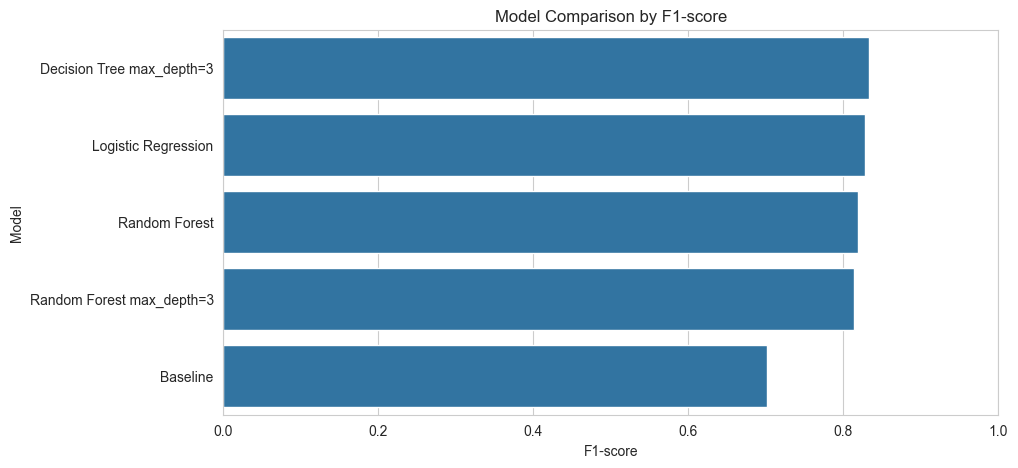

In [90]:
# Plot F1-score comparison

plt.figure(figsize=(10, 5))

sns.barplot(data=final_results_sorted, x="F1-score", y="Model")

plt.title("Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()


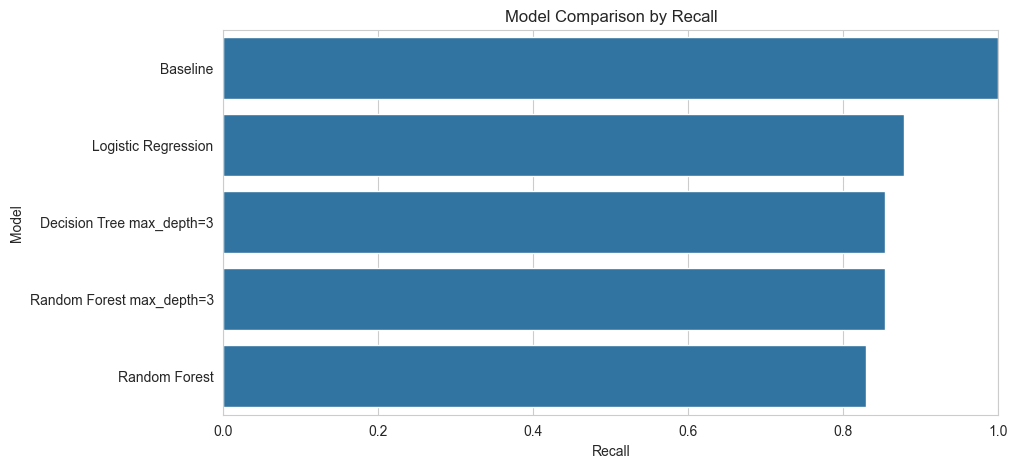

In [91]:
# Sort models by recall

recall_sorted = final_results.sort_values(by="Recall", ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(data=recall_sorted, x="Recall", y="Model")

plt.title("Model Comparison by Recall")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()


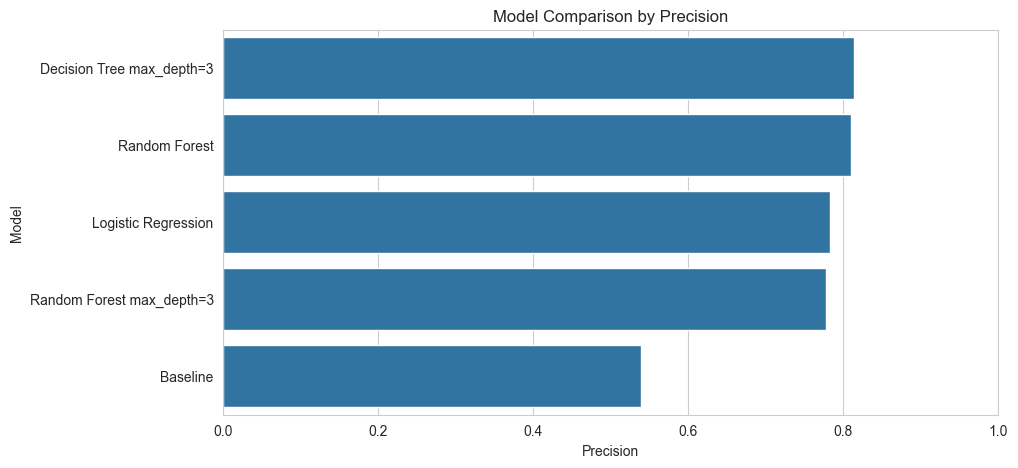

In [92]:
# Sort models by precision

precision_sorted = final_results.sort_values(by="Precision", ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(data=precision_sorted, x="Precision", y="Model")

plt.title("Model Comparison by Precision")
plt.xlabel("Precision")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()


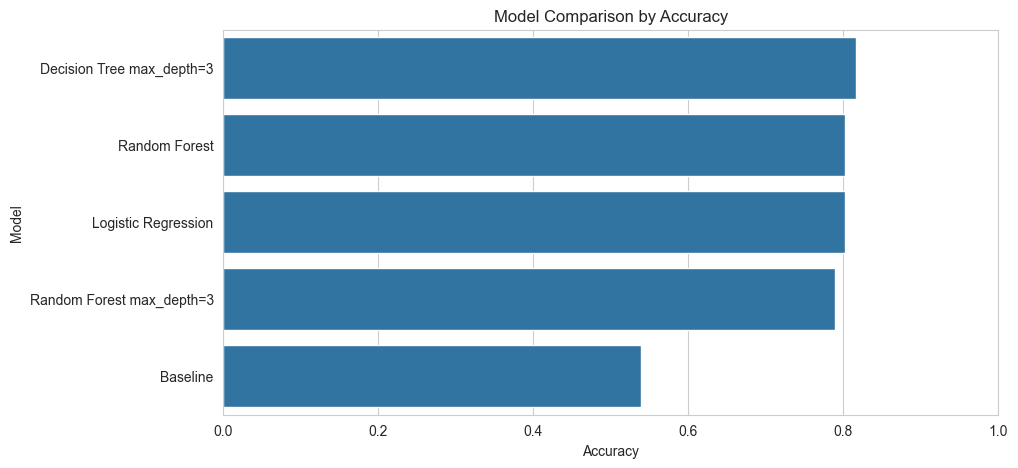

In [93]:
# Sort models by accuracy

accuracy_sorted = final_results.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(data=accuracy_sorted, x="Accuracy", y="Model")

plt.title("Model Comparison by Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()


### All Metrics Comparison

I also compare all main metrics together.

This makes the trade-off between accuracy, precision, recall, and F1-score easier to see.


In [94]:
# Convert final_results to long format for grouped bar chart

metrics_long = final_results.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"], var_name="Metric", value_name="Score")

metrics_long.head()


,Model,Metric,Score
0,Baseline,Accuracy,0.539474
1,Logistic Regression,Accuracy,0.802632
2,Decision Tree max_depth=3,Accuracy,0.815789
3,Random Forest,Accuracy,0.802632
4,Random Forest max_depth=3,Accuracy,0.789474


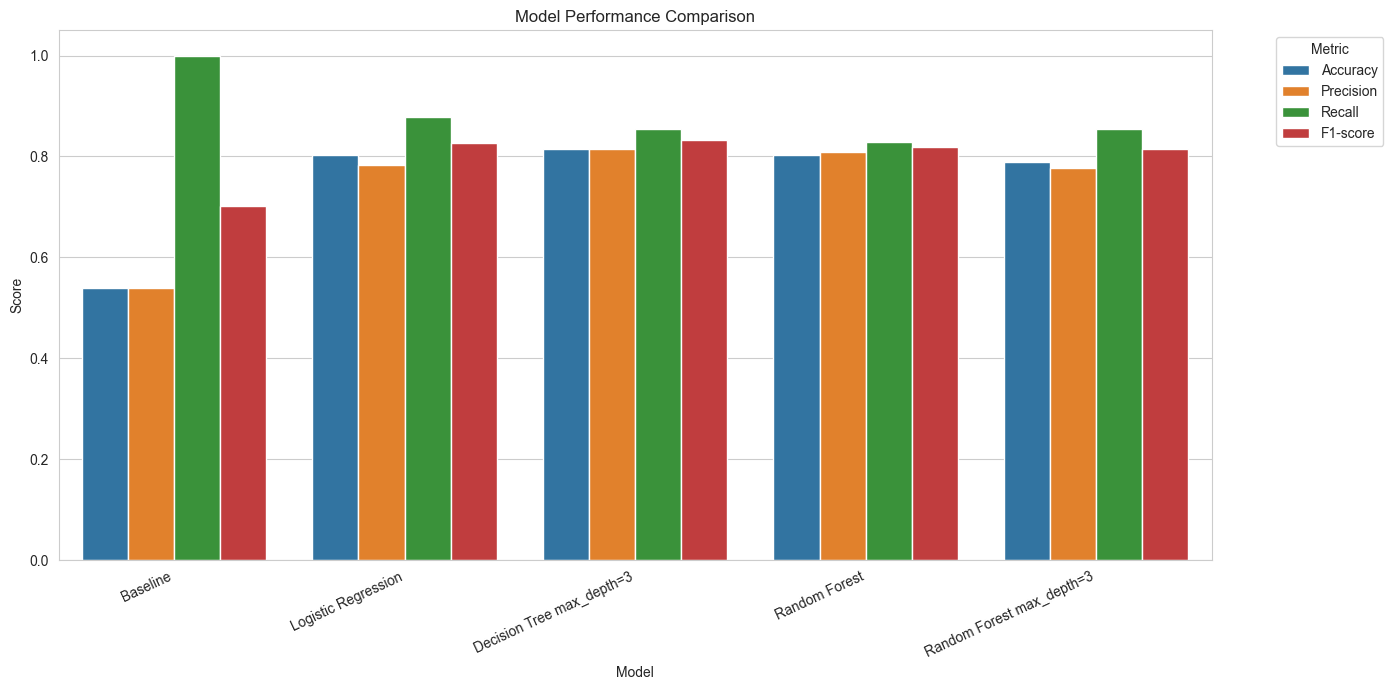

In [95]:
plt.figure(figsize=(14, 7))

sns.barplot(data=metrics_long, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Cross-Validation Performance Visualization

Next, I visualize the cross-validation results.

This gives a more stable view of model performance because each model is evaluated across several different folds.


In [96]:
cv_results_plot = cv_results_df.copy()
cv_metrics_long = cv_results_plot.melt(id_vars='Model', value_vars=['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1-score'], var_name='Metric',
    value_name='Score'
)
cv_metrics_long.head()

,Model,Metric,Score
0,Baseline,CV Accuracy,0.544251
1,Logistic Regression,CV Accuracy,0.813913
2,Decision Tree max_depth=3,CV Accuracy,0.747343
3,Random Forest,CV Accuracy,0.835845
4,Random Forest max_depth=3,CV Accuracy,0.844831


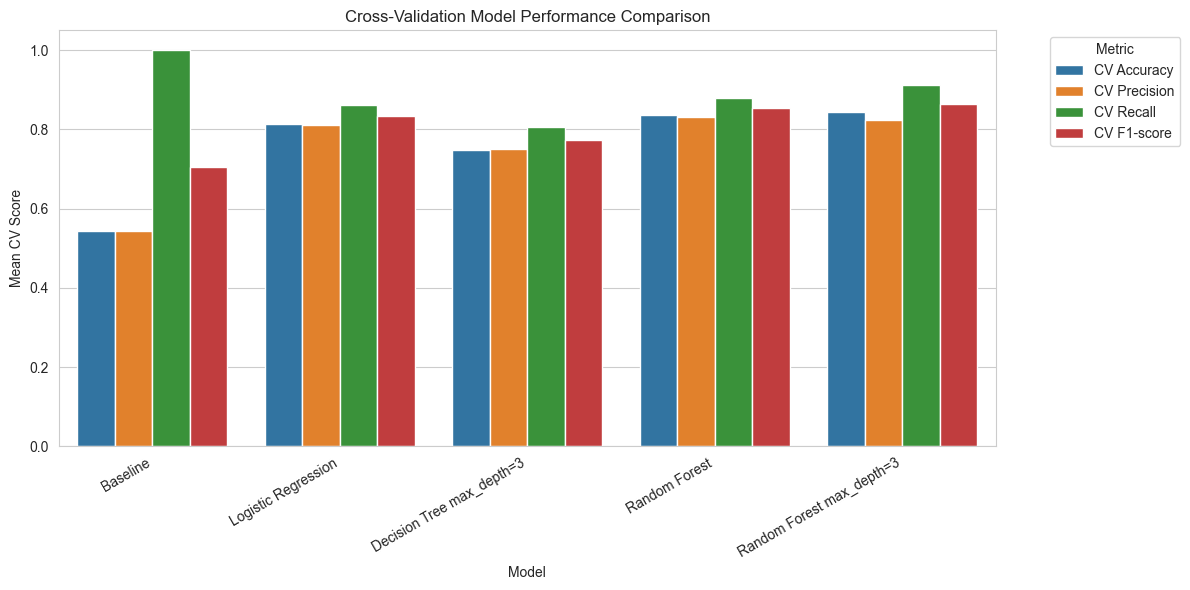

In [97]:
# Plot cross-validation metrics together

plt.figure(figsize=(12, 6))

sns.barplot(data=cv_metrics_long, x="Model", y="Score", hue="Metric")

plt.title("Cross-Validation Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean CV Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Cross-Validation F1-score Comparison

I focus separately on CV F1-score because it balances precision and recall.

Based on this metric, Random Forest has the strongest average performance across folds.


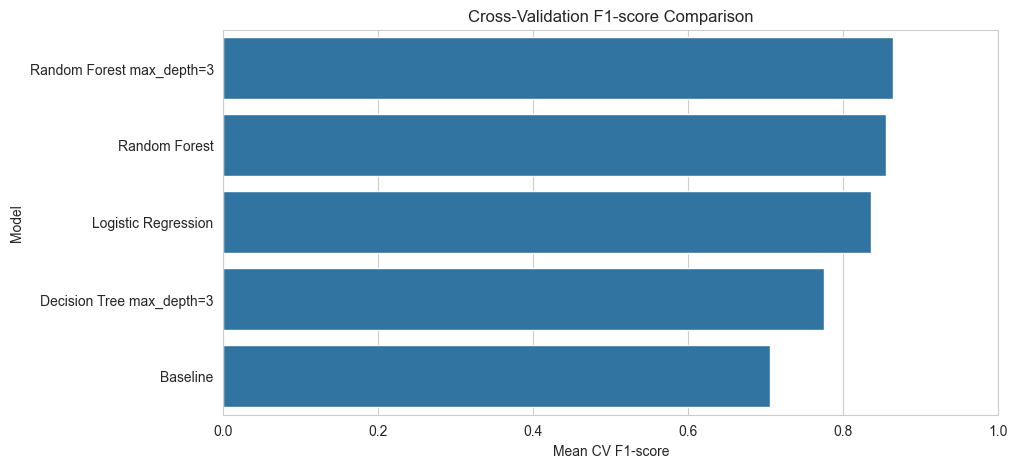

In [98]:
# Visualize cross-validation F1-score

plt.figure(figsize=(10, 5))

sns.barplot(data=cv_results_sorted, x="CV F1-score", y="Model")

plt.title("Cross-Validation F1-score Comparison")
plt.xlabel("Mean CV F1-score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()


### Model Performance Visualization Observation

Single test set and cross-validation give slightly different rankings.

On the test set: Decision Tree `max_depth=3` had the best F1 and recall. In cross-validation: Random Forest averaged best across five folds.

With 303 samples, I trust CV more. The test set result could easily shift with a different split. CV gives a more stable picture of which model actually generalizes better — and that's Random Forest.


### Confusion Matrix Comparison — All Models

Accuracy and F1-score summarize performance in one number, but confusion matrices show where each model makes mistakes.

For this task, false negatives are especially important because they mean missed sick patients.


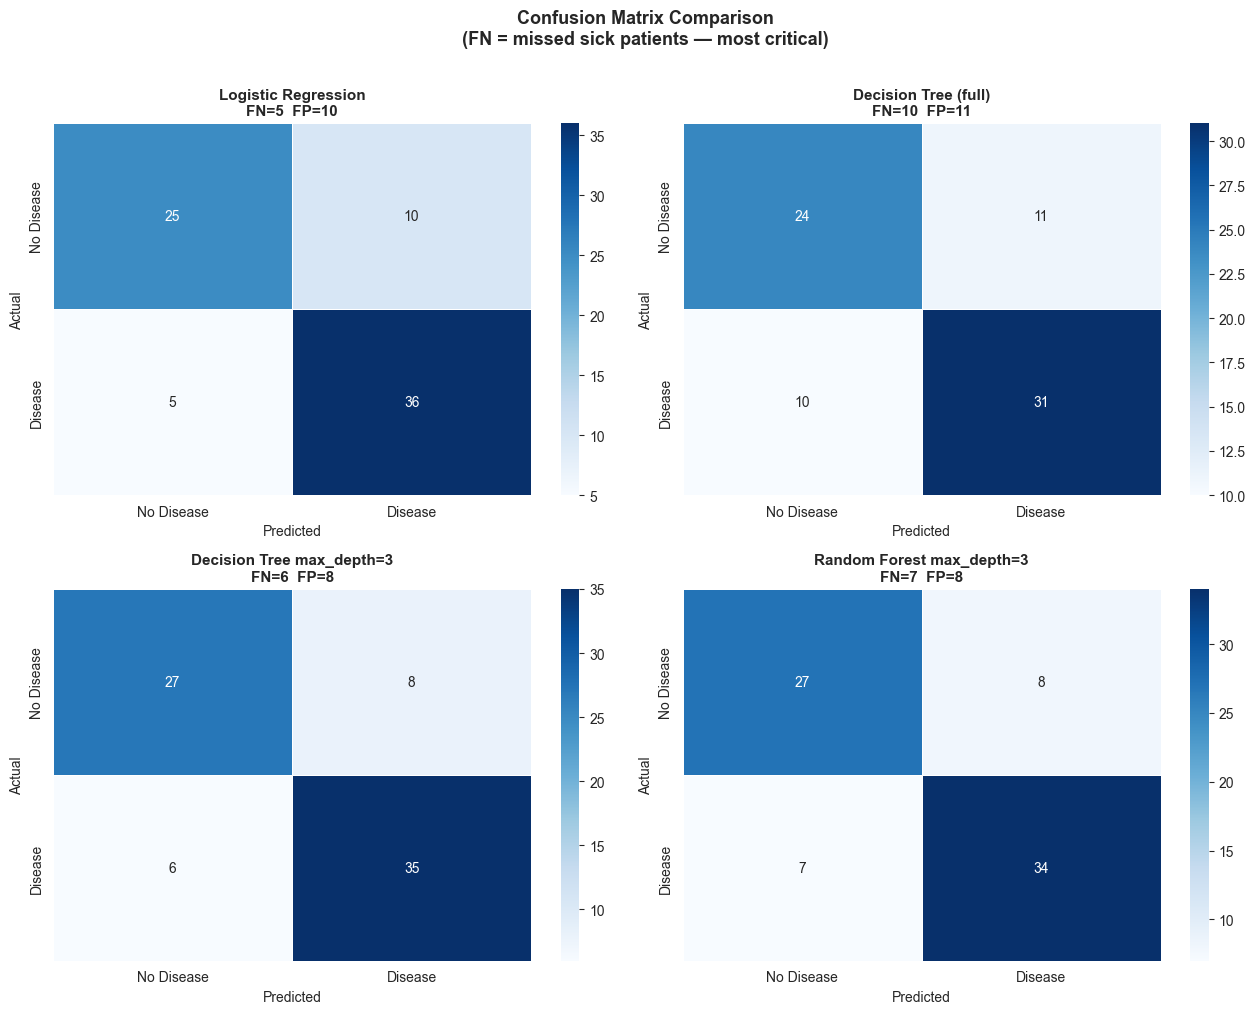

In [106]:
# Collect model names and their predictions
cm_models = [
    ('Logistic Regression',       log_reg_predictions),
    ('Decision Tree (full)',       tree_predictions),
    ('Decision Tree max_depth=3', final_tree_pred),
    ('Random Forest max_depth=3',             rf_predictions),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, cm_models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease'],
        ax=ax, linewidths=0.5
    )
    # Calculate false negatives from confusion matrix
    fn = cm[1, 0]  
    fp = cm[0, 1]   
    ax.set_title(f'{name}\nFN={fn}  FP={fp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison\n(FN = missed sick patients — most critical)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Confusion Matrix Comparison Observation

The confusion matrices show that the models make different types of mistakes.

For a medical task, I pay special attention to false negatives. A lower false negative count is usually better here, even if there is some trade-off with false positives.


## 13. Best Model Selection

Random Forest — selected based on cross-validation F1-score, not test set performance.

Using the test set to pick the final model would mean optimizing for that specific split. The test set should stay untouched until the very end, used once for the final evaluation. Everything before that — including model selection — goes through CV.

The Decision Tree experiments were still useful: they showed overfitting concretely and made the regularization argument clear.


In [105]:
# Save the best model and its predictions

best_model = random_forest
best_model_name = "Random Forest max_depth=3"
best_model_predictions = rf_predictions


## 14. Confusion Matrix for the Best Model

After selecting the best model, I analyze its confusion matrix.

This helps me see what types of mistakes the final Random Forest `max_depth=3`makes on the test set.


In [101]:
best_model_cm = confusion_matrix(y_test, best_model_predictions)

best_model_cm


array([[27,  8],
       [ 7, 34]])

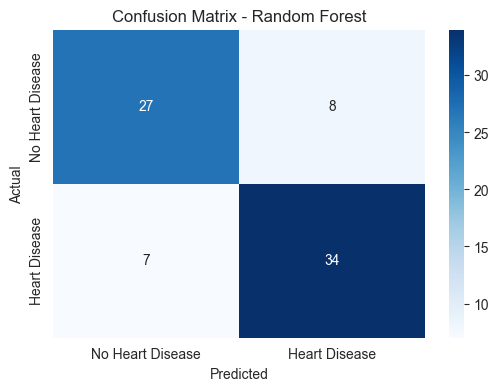

In [102]:
# Visualize confusion matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    best_model_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"])

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## 15. Feature Importance

After selecting Random Forest `max_depth=3` as the final model, I check feature importance.

This helps me understand which input features were most useful for the model when making predictions.


In [103]:
# Get feature importance from the final Random Forest model

feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
2,chest_pain_type,0.167502
7,max_heart_rate,0.134082
9,st_depression,0.112393
11,num_major_vessels,0.101139
12,thal,0.097611
0,age,0.082143
3,resting_blood_pressure,0.076847
4,cholesterol,0.075649
8,exercise_angina,0.051917
10,slope,0.036178


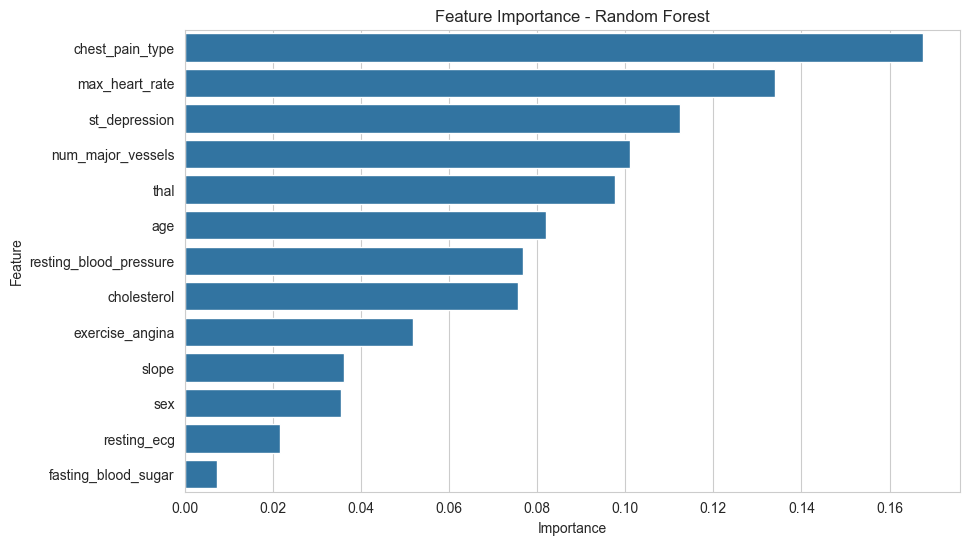

In [104]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

sns.barplot(data=feature_importance, x="Importance", y="Feature")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


### Feature Importance Observation

Top features: `num_major_vessels`, `chest_pain_type`, `max_heart_rate`, `st_depression`, `thal`.

These are the same features that showed the clearest class separation in EDA — both in the visualizations and in the correlation analysis. EDA and model importance agree, which is a reasonable sanity check. If they disagreed significantly, I'd want to understand why before trusting the model.

`cholesterol` and `fasting_blood_sugar` rank low — consistent with what the EDA already showed.


## 16. Project Limitations

Dataset size. After deduplication: ~303 rows. Small enough that individual predictions shift the metrics visibly. Cross-validation helps but doesn't fully solve this.

Single source. All patients come from one UCI study. A model trained here might not transfer to patients from different hospitals or demographic groups. Real medical ML requires external validation — this project doesn't do that.

No hyperparameter search. I tested `max_depth` manually for a small range. A proper GridSearchCV would be more thorough and less prone to missing a better configuration.


## 17. Possible Improvements

GridSearchCV for hyperparameter tuning — systematic search instead of manual testing.

ROC curve and AUC — standard evaluation tool for binary classification, shows the precision-recall tradeoff across all decision thresholds. More informative than a single F1 score for medical tasks.

Feature selection — `cholesterol` and `fasting_blood_sugar` showed near-zero predictive value throughout the project. Removing them and retraining might reduce noise on a small dataset.

External validation — test the final model on a genuinely separate dataset to check whether it generalizes beyond this specific sample.


## 18. Final Conclusion

Full binary classification pipeline for heart disease prediction — data checks, EDA, three models, cross-validation, final selection.

A few things this project made concrete:

Model selection depends on evaluation method. Decision Tree ranked first on the test set, Random Forest ranked first in CV. On a small dataset, CV is more trustworthy. Picking based on one split is risky.

Overfitting is visible in the numbers. Train accuracy 1.0, test accuracy 0.80 — the gap is a clear warning sign.. Regularization (`max_depth`) fixed it, at a small cost to training performance.

EDA and model importance should agree. They did here. If they hadn't, it would be worth investigating before trusting the model's output.

Data leakage is easy to miss. Scaling before splitting, or removing duplicates after splitting — both look harmless but corrupt the evaluation. Order of operations matters.

Final model: Random Forest, `n_estimators=100`, selected by CV F1-score.
